In [1]:
cd plots

/arc7/home/dboyea/surp/carbon_paper/plots


/astro/dboyea/.local/lib/python3.11/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [6]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import transforms
import numpy as np

import arya

import vice
import surp
from surp.gce_math import MH_to_Z, Z_to_MH
from surp.agb_interpolator import interpolator as agb_interpolator

import sys
sys.path.append("..")
from yield_plot_utils import AGB_MODELS, AGB_LABELS, plot_yield_table, hmap, plot_y_z, plot_ssp_time




 
 


/astro/dboyea/.local/lib/python3.11/site-packages/vice-1.4.0.dev0-py3.11-linux-x86_64.egg/vice/__init__.py:141: UserWarning: Using un-released version of VICE
  warnings.warn("Using un-released version of VICE", UserWarning)


In [22]:
def plot_y_agb(fig, ax):
    SCALE_FACTOR=1e2

    study = AGB_MODELS[0]
    label = AGB_LABELS[study]
    f = plot_yield_table(study, ax=ax, 
                         fig=fig, fmt="o", factor=SCALE_FACTOR)
    
    # plot label
    plt.annotate(xy=(0,0), xytext=(8,8), 
                 text="FRUITY",
                 xycoords="axes fraction", textcoords="offset points",
                 horizontalalignment='left',
                verticalalignment='bottom')
        

    handles, labels = plt.gca().get_legend_handles_labels()
    arya.Legend(handles=handles[::2], labels=labels[::2], color_only=True, fontsize=8)



    plt.xlabel(r'initial mass / ${\rm M}_\odot$')
    plt.ylabel(r"stellar C yield $\quad[\times 10^{-2}]$")

    plt.gca().xaxis.set_minor_locator(mpl.ticker.AutoMinorLocator(2))




In [23]:
def plot_y_agb_vs_z():
    x_min = -2.8
    x_max = 0.6
    N_points = 100
    scale = 1e4
    ele = "c"

    vice.yields.ccsne.settings[ele] = 0
    vice.yields.sneia.settings[ele] = 0

    text_x = x_min
    text_y = [10, 6, 14.5, 19]

    for i in range(4):
        model = AGB_MODELS[i]

        vice.yields.agb.settings[ele] = agb_interpolator(ele, study=model)
        kwargs = dict(fmt="o", zorder=i, factor=scale, color=arya.COLORS[i])
        
        # plots importaint points
        _y1, _m1, Zs = vice.yields.agb.grid('c', study=model)
        (line,), _x = plot_y_z(Zs, **kwargs)
        
        # plot solid within range
        MoverH_min = Z_to_MH(min(Zs))
        MoverH_max = Z_to_MH(max(Zs))
        
        kwargs["fmt"] = "-"
        Zs = MH_to_Z(np.linspace(MoverH_min, MoverH_max, N_points))
        plot_y_z(Zs, label=AGB_LABELS[model], **kwargs)

        # dashed extrapolation
        kwargs["fmt"] = "--"
        Zs = MH_to_Z(np.linspace(x_min, MoverH_min, N_points))    
        plot_y_z(Zs, **kwargs)
        Zs = MH_to_Z(np.linspace(MoverH_max, x_max, N_points))
        plot_y_z(Zs, **kwargs)

        plt.annotate(xy=(text_x,text_y[i]), xytext=(2,0), 
                     text=AGB_LABELS[model], color=arya.COLORS[i],
                     fontsize=8,
                     xycoords="data", textcoords="offset points",
                     horizontalalignment='left',
                    verticalalignment='center')


    plt.ylabel(r"integrated AGB C yield $ [\times 10^{-4}]$")



In [17]:
def plot_text_on_curve(
    ax,
    xs,
    ys,
    x_anchor,
    text,
    h = 0.01,
    offset=(0, 0),
    ha="center",
    va="bottom",
    extra_rotation=0,
    **text_kwargs,
):
    """
    Plot text at a given x-coordinate along a curve, rotated to match the curve's slope.
 
    Parameters
    ----------
    ax : matplotlib.axes.Axes
        The axes on which to draw.
    xs : array-like
        x-coordinates of the curve (must be monotonically increasing).
    ys : array-like
        y-coordinates of the curve (same length as xs).
    x_anchor : float
        The x-coordinate at which the label should be placed.
    text : str
        The string to render.
    offset : (float, float), optional
        (dx, dy) shift in *points* applied perpendicular to the reading direction,
        so the label floats above (or below) the curve rather than sitting on it.
        Default is (0, 8) – 8 pt above.
    ha : str, optional
        Horizontal alignment of the text ('left', 'center', 'right').  Default 'center'.
    va : str, optional
        Vertical alignment of the text ('top', 'center', 'bottom').  Default 'bottom'.
    **text_kwargs
        Any additional keyword arguments forwarded to ax.text()
        (e.g. fontsize, color, fontweight, bbox, …).
 
    Returns
    -------
    matplotlib.text.Text
        The Text artist that was added to the axes.
 
    Notes
    -----
    * xs must be **strictly increasing** (or at least monotone) so that
      np.interp can find a unique y and slope at x_anchor.
    * The rotation angle is derived from the slope in *data* coordinates and
      then converted to the display / figure coordinate system so that the
      rendered text matches the visual angle of the curve, regardless of axis
      aspect ratio or figure size.
    * Works with both linear and log10 x-axis scales (set via
      ax.set_xscale('log')).  The step used for slope estimation is taken in
      log space when the axis is logarithmic, so the tangent is accurate at
      any decade.
    """
    xs = np.asarray(xs, dtype=float)
    ys = np.asarray(ys, dtype=float)
    xlim = ax.get_xlim()
 
    # ------------------------------------------------------------------ #
    # 1.  Interpolate y at the anchor                                     #
    # ------------------------------------------------------------------ #
    y_anchor = float(np.interp(x_anchor, xs, ys))
 
    # ------------------------------------------------------------------ #
    # 2.  Estimate the slope (dy/dx) at x_anchor via central differences  #
    #     on the interpolated neighbourhood.                              #
    # ------------------------------------------------------------------ #
    # On a log x-axis the visual spacing is proportional to log10(x), so
    # we choose a step that is 1 % of the axis span *in log space* and then
    # convert back to data coordinates.  On a linear axis we fall back to
    # the original 1 % of the data range.
    x_scale = ax.get_xscale()
    if x_scale == "log":
        log_left  = np.log10(xlim[0])
        log_right = np.log10(xlim[1])
        dlog      = (log_right - log_left) * h
        x_left    = max(10 ** (np.log10(x_anchor) - dlog), xs[0])
        x_right   = min(10 ** (np.log10(x_anchor) + dlog), xs[-1])
    else:
        dx_step = (xlim[1] - xlim[0]) * h
        x_left  = max(x_anchor - dx_step, xs[0])
        x_right = min(x_anchor + dx_step, xs[-1])
 
    print("x slope", x_left, x_right)
    y_left  = float(np.interp(x_left,  xs, ys))
    y_right = float(np.interp(x_right, xs, ys))
 
    # Slope in data coordinates.
    if x_scale == "log":
        # take log-average slope
        #slope_data = (y_right - y_left) / (np.log10(x_right) - np.log10(x_left)) if x_right != x_left else 0.0

        #slope_data *= 1 / (x_anchor * np.log(10))

        slope_data = (y_right - y_left) / (x_right - x_left) if x_right != x_left else 0.0

    else:
        slope_data = (y_right - y_left) / (x_right - x_left) if x_right != x_left else 0.0

    print("slope", slope_data)
 
    # ------------------------------------------------------------------ #
    # 3.  Convert the slope to display (pixel) coordinates so that the   #
    #     text angle matches the *visual* angle of the curve.            #
    # ------------------------------------------------------------------ #
    # We map two data-space points separated by the slope vector into
    # display space and measure the angle there.
    # x_right is used as the second point (works for both linear and log).
    data_to_display = ax.transData
 
    p0 = data_to_display.transform((x_anchor,  y_anchor))
    p1 = data_to_display.transform((x_right,   y_anchor + slope_data * (x_right - x_anchor)))
 
    dx_disp = p1[0] - p0[0]
    dy_disp = p1[1] - p0[1]
 
    angle_deg = float(np.degrees(np.arctan2(dy_disp, dx_disp))) + extra_rotation
 
    angle = np.deg2rad(angle_deg)
    # ------------------------------------------------------------------ #
    # 4.  Place the text, applying the pixel offset *after* rotation.    #
    # ------------------------------------------------------------------ #
    # We use a combined transform: data → display, then a translation in
    # points.  The offset is in the un-rotated (screen-axis) frame, which
    # means dy shifts the label perpendicular to the baseline.
    offset_rotated = [
            offset[0] * np.cos(angle) - offset[1] * np.sin(angle),
            offset[0] * np.sin(angle) + offset[1] * np.cos(angle),
            ]

    offset_transform = transforms.ScaledTranslation(
        offset_rotated[0] / 72,  # points → inches
        offset_rotated[1] / 72,
        ax.figure.dpi_scale_trans,
    )
    combined = data_to_display + offset_transform
 
    t = ax.text(
        x_anchor,
        y_anchor,
        text,
        rotation=angle_deg,
        rotation_mode="anchor",
        ha=ha,
        va=va,
        transform=combined,
        **text_kwargs,
    )
    return t

In [18]:
def main():
    fig, axs = plt.subplots(1, 3, figsize=(7, 2.5))

    plt.sca(axs[0])
    axs[0].set_box_aspect(1)
    plot_y_agb(fig, axs[0])

    plt.sca(axs[1])
    axs[1].set_box_aspect(1)
    plot_y_agb_vs_z()

    plt.sca(axs[2])
    axs[2].set_box_aspect(1)
    plot_y_agb_vs_t()

    plt.tight_layout()


In [35]:

def plot_y_agb_vs_t():
    vice.yields.ccsne.settings["c"] = 0
    vice.yields.sneia.settings["c"] = 0
    vice.yields.ccsne.settings["fe"] = 0
    vice.yields.agb.settings["fe"] = surp.yield_models.ZeroAGB()
    text_x = [0.5, 1, 0.7, 0.9]
    text_va = ["top", "top", "bottom", "bottom"]
    extra_rotations = [-3, 0, -5, -3]

    plt.ylim(-0.3, 1.2)
    plt.xlim(0.03, 13.2)

    for i in range(4):
        model = AGB_MODELS[i]
        vice.yields.agb.settings["c"] = agb_interpolator("c", study=model)
        times, y = plot_ssp_time(Z=surp.gce_math.MH_to_Z(-0.1), label=AGB_LABELS[model])
        if i == 0:
            offset = (0, -2)
        elif i == 1:
            offset = (0, -2)
        else:
            offset = (0, 1)

        plot_text_on_curve(plt.gca(), times, y, text_x[i], AGB_LABELS[model], 
                           color=arya.COLORS[i], fontsize=8, va=text_va[i], offset=offset,
                          extra_rotation=extra_rotations[i])


      
        
    times, y = plot_ssp_time("fe", color="k", ls="--", zorder=-1)
    plot_text_on_curve(plt.gca(), times, y, 3, "SN Ia Fe", va="top", offset=(0, -2), extra_rotation=-6)

    plt.xticks([0.1, 1, 10], labels=[0.1, 1, 10])
    plt.ylabel("cumulative AGB C production")
    plt.xlabel("time / Gyr")

model = 1.00 × cristallo11
t1/2 = 0.79
y(t>1.01) = 0.35
y max = 1.03
y min = -0.15
t min = 0.21

x slope 0.4704738372234869 0.5313791760991031
slope 1.298712556891737
model = 1.00 × ventura13
t1/2 = 1.39
y(t>1.01) = 0.94
y max = 1.00
y min = -3.01
t min = 0.30

x slope 0.9409476744469737 1.0627583521982062
slope 1.8944364280695574
model = 1.00 × karakas16
t1/2 = 0.38
y(t>1.01) = -0.02
y max = 1.07
y min = -0.16
t min = 0.12

x slope 0.6586633721128816 0.7439308465387443
slope 0.6068275257863979
model = 1.00 × battino19
t1/2 = 0.56
y(t>1.01) = 0.25
y max = 1.00
y min = -0.07
t min = 0.10

x slope 0.8468529070022764 0.9564825169783856
slope 0.4317480104108143
model = 0
t1/2 = 0.96
y(t>1.01) = 0.49
y max = 1.00
y min = 0.00
t min = 0.00

x slope 2.8228430233409214 3.1882750565946183
slope 0.07115615117159903


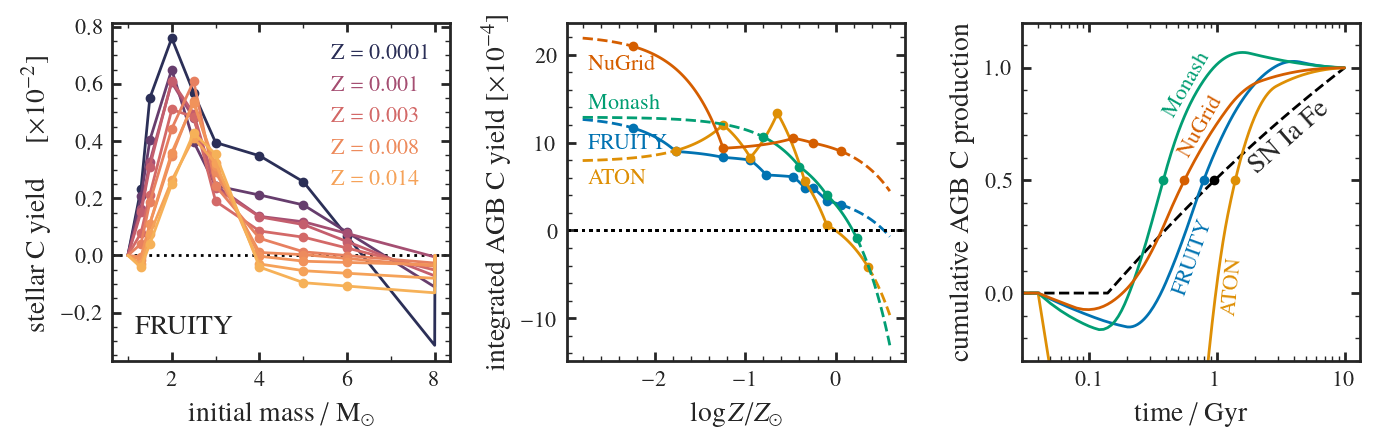

In [36]:
main()